In [1]:
import pandas as pd
import plotly.express as pl
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('E:/Data_Mining_project/data/final_data.csv')
df.head()

,Country Name,Indicator Name,1990,1991,1992,1993,1994,1995,1996,1997,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Africa Eastern and Southern,Carbon dioxide (CO2) emissions (total) excludi...,378.504400,370.704200,364.366500,364.464100,372.785400,392.550300,407.217700,423.815000,...,635.629700,621.866500,628.536500,637.906800,645.836700,654.540100,578.052000,606.394500,588.433500,579.865500
1,Africa Eastern and Southern,Carbon dioxide (CO2) emissions excluding LULUC...,1.232869,1.174578,1.123988,1.093279,1.088836,1.117248,1.128710,1.145022,...,1.096416,1.043373,1.026116,1.012873,0.997157,0.983492,0.845417,0.863533,0.816361,0.784641
2,Africa Eastern and Southern,"Life expectancy at birth, total (years)",51.096326,50.873244,50.715946,51.073762,50.966589,51.482057,51.353190,51.570887,...,61.251436,61.713031,62.167981,62.591275,63.330691,63.857261,63.766484,62.979999,64.487020,65.146291
3,Africa Eastern and Southern,"PM2.5 air pollution, mean annual exposure (mic...",25.111399,24.547886,24.155248,23.906832,23.753597,23.721569,24.058755,24.788241,...,27.779344,29.515468,28.877274,27.311377,27.404295,26.248200,26.755686,26.612640,26.612640,26.612640
4,Africa Eastern and Southern,Total greenhouse gas emissions excluding LULUC...,42.315217,-1.404289,-1.262742,-0.617957,2.861028,7.196559,11.108544,14.497652,...,69.273682,68.932387,71.473734,73.477157,76.040251,79.837760,73.221328,75.906074,75.921243,76.382350


In [8]:
# create dataset with two indicators with different columns of indicator names like merge them all data is same but indicator name divide into different columns
co2 = df.loc[df['Indicator Name'] == 'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)']
co2_total = df.loc[df['Indicator Name'] == 'Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)']
life = df.loc[df['Indicator Name'] == 'Life expectancy at birth, total (years)']
pm25 = df.loc[df['Indicator Name'] == 'PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)']
# melt these three datasets on country name and year
cols_to_melt = [col for col in df.columns if col.startswith('19') or col.startswith('20')] 
# adjust the condition for melting above three datasets
co2_melted = co2.melt(id_vars=['Country Name', 'Indicator Name'], 
                      value_vars=cols_to_melt,
                      var_name='Year',
                      value_name='CO2_value')
co2_total_melted = co2_total.melt(id_vars=['Country Name', 'Indicator Name'],
                                  value_vars=cols_to_melt,
                                  var_name='Year',
                                  value_name='co2_total')
life_melted = life.melt(id_vars=['Country Name', 'Indicator Name'], 
                        value_vars=cols_to_melt,
                        var_name='Year',
                        value_name='Life_value')
pm25_melted = pm25.melt(id_vars=['Country Name', 'Indicator Name'], 
                        value_vars=cols_to_melt,
                        var_name='Year',
                        value_name='PM2.5_value')
# merge these three datasets on country name and year
# columns are country name , year, co2 indicator, co2_value, life expectancy indicator, life_value, pm25 indicator, pm25_value
merged_df = pd.merge(co2_melted, life_melted, on=['Country Name', 'Year'], suffixes=('_co2', '_life'))
merged_df = pd.merge(merged_df, pm25_melted, on=['Country Name', 'Year'], suffixes=('_co2_life', '_pm25'))
merged_df = pd.merge(merged_df, co2_total_melted, on=['Country Name', 'Year'], suffixes=('', '_total'))
# Rename columns for clarity and drop unnecessary indicator columns
merged_df = merged_df.rename(columns={
    'Indicator Name_co2': 'CO2_Indicator',
    'Indicator Name_life': 'Life_Indicator',
    'Indicator Name': 'PM25_Indicator'
})
# Select and reorder the columns
merged_df = merged_df[['Country Name', 'Year', 'CO2_Indicator', 'CO2_value', 'Life_Indicator', 'Life_value', 'PM25_Indicator', 'PM2.5_value','Indicator Name_total','co2_total']]
merged_df.head()

,Country Name,Year,CO2_Indicator,CO2_value,Life_Indicator,Life_value,PM25_Indicator,PM2.5_value,Indicator Name_total,co2_total
0,Africa Eastern and Southern,1990,Carbon dioxide (CO2) emissions excluding LULUC...,1.232869,"Life expectancy at birth, total (years)",51.096326,"PM2.5 air pollution, mean annual exposure (mic...",25.111399,Carbon dioxide (CO2) emissions (total) excludi...,378.5044
1,Africa Western and Central,1990,Carbon dioxide (CO2) emissions excluding LULUC...,0.490402,"Life expectancy at birth, total (years)",48.459295,"PM2.5 air pollution, mean annual exposure (mic...",60.240684,Carbon dioxide (CO2) emissions (total) excludi...,102.7717
2,Arab World,1990,Carbon dioxide (CO2) emissions excluding LULUC...,3.054164,"Life expectancy at birth, total (years)",62.755973,"PM2.5 air pollution, mean annual exposure (mic...",40.315707,Carbon dioxide (CO2) emissions (total) excludi...,675.5995
3,Caribbean small states,1990,Carbon dioxide (CO2) emissions excluding LULUC...,4.685017,"Life expectancy at birth, total (years)",67.045151,"PM2.5 air pollution, mean annual exposure (mic...",24.253146,Carbon dioxide (CO2) emissions (total) excludi...,17.1235
4,Central Europe and the Baltics,1990,Carbon dioxide (CO2) emissions excluding LULUC...,9.679323,"Life expectancy at birth, total (years)",70.656331,"PM2.5 air pollution, mean annual exposure (mic...",27.015725,Carbon dioxide (CO2) emissions (total) excludi...,1071.9185


In [7]:
# line plot using plotly express for CO2 emissions over years for a specific country
country_name = 'Pakistan'
fig = pl.line(merged_df[merged_df['Country Name'] == country_name], x='Year', y='CO2_value',
               title=f'CO2 Emissions per capita over Years for {country_name}')
fig.show()
# line plot for total co2 emissions
country_name = 'Pakistan'
fig = pl.line(merged_df[merged_df['Country Name'] == country_name], x='Year', y='co2_total',
               title=f' Total CO2 Emissions over Years for {country_name}')
fig.show()
# line plot using plotly express for Life expectancy over years for a specific country
fig = pl.line(merged_df[merged_df['Country Name'] == country_name], x='Year', y='Life_value',
               title=f'Life Expectancy over Years for {country_name}')
fig.show()
# line plot using plotly express for PM2.5 levels over years for a specific country 
fig = pl.line(merged_df[merged_df['Country Name'] == country_name], x='Year', y='PM2.5_value',
               title=f'PM2.5 Levels over Years for {country_name}')
fig.show()

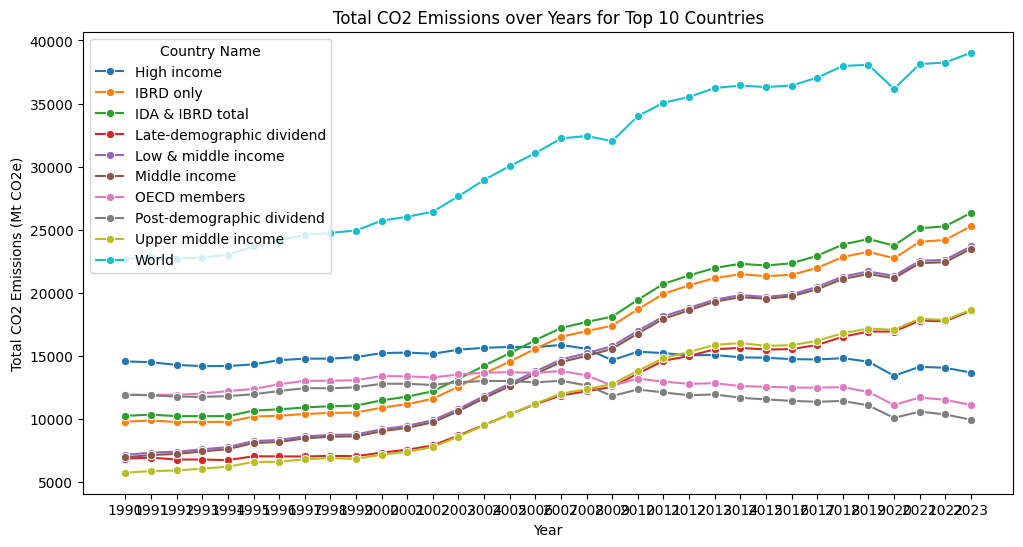

In [8]:
# total co2 emissions plot for top 10 countries
top10_countries = merged_df.groupby('Country Name')['co2_total'].mean().nlargest(10).index
top10_df = merged_df[merged_df['Country Name'].isin(top10_countries)]
plt.figure(figsize=(12, 6))
sns.lineplot(data=top10_df, x='Year', y='co2_total', hue='Country Name', marker='o')
plt.title('Total CO2 Emissions over Years for Top 10 Countries')
plt.xlabel('Year')
plt.ylabel('Total CO2 Emissions (Mt CO2e)')
plt.legend(title='Country Name')
plt.show()

In [9]:
# average co2 emissions of all countries over years by plotly 
avg_co2_df = merged_df.groupby('Year')['CO2_value'].mean().reset_index()
fig = pl.line(avg_co2_df, x='Year', y='CO2_value',
                title='Average CO2 Emissions per capita over Years for All Countries')
fig.show()

In [10]:
# total co2 emissions mt co2e tone plot of all countries over years by plotly 
# Carbon dioxide (CO2) emissions (total) excludi..
avg_total_co2_df = merged_df.groupby('Year')['co2_total'].mean()
fig = pl.line(avg_total_co2_df.reset_index(), x='Year', y='co2_total',
                title='Average Total CO2 Emissions (Mt CO2e) over Years for All Countries')
fig.show()

In [17]:
# total co2 emissions mt co2e tone plot of all countries over years by plotly 
# Carbon dioxide (CO2) emissions (total) excludi..
avg_total_co2_df = merged_df.groupby('Year')['co2_total'].mean().reset_index()
fig = pl.line(avg_total_co2_df, x='Year', y='co2_total',
                title='Average Total CO2 Emissions (Mt CO2e) over Years for All Countries')
fig.show()

In [38]:
# co2 emissons in ppm value plot by plotly mt co2e tone
fig = pl.line(merged_df, x='Year', y='CO2_value',
                title='CO2 Emissions per capita (t CO2e/capita) over Years for All Countries')
# bullets at line top and shado of background paper
fig.update_traces(mode='lines+markers')
fig.show()

In [30]:
# Carbon dioxide (CO2) emissions (total) excludi...	plot by plotly in ppm value
fig = pl.line(merged_df, x='Year', y='co2_total',
                title='Total CO2 Emissions (Mt CO2e) over Years for All Countries')
# make bullets at line top and shado of background paper
fig.update_traces(mode='lines+markers')
fig.show()

In [ ]:
co2 = pl.line(merged_df, x='Year', y='co2_total', color='Country Name',
                title='CO2 Emissions over Years for All Countries',
                )
co2.show()

In [28]:
# plotly graph showing co2 concentration over years
fig = pl.line(merged_df, x='Year', y='CO2_value',
                title='CO2 Concentration over Years for All Countries')
# fig make at the top of lines a bullets
fig.update_traces(mode='lines+markers')
# make dark color in plot lines
fig.update_traces(line=dict(color='black'))
fig.show()

In [11]:
# co2 plot of country name south asia plotly line plot
south = merged_df.loc[merged_df['Country Name'].isin(['India', 'Pakistan', 'Bangladesh', 'Sri Lanka', 'Nepal', 'Bhutan'])]  
fig = pl.line(south, x='Year', y='CO2_value', color='Country Name',
                title='CO2 Emissions per capita over Years for South Asian Countries')
fig.show()

In [14]:
south_region = merged_df.loc[merged_df['Country Name'].isin(['South Asia'])]
fig = pl.line(south_region, x='Year', y='CO2_value', color='Country Name',
              title='CO2 Emissions per capita over Years for South Asia Region')
fig.show()

In [15]:
south_region = merged_df.loc[merged_df['Country Name'].isin(['South Asia'])]
fig = pl.line(south_region, x='Year', y='co2_total', color='Country Name',
              title='CO2 Emissions per capita over Years for South Asia Region')
fig.show()

In [17]:
south_region = merged_df.loc[merged_df['Country Name'].isin(['South Asia'])]
fig = pl.line(south_region, x='Year', y='Life_value', color='Country Name',
              title='Life Expectancy over Years for South Asia Region')
fig.show()

In [19]:
# create a miltiline plot of region_data with co2_total and life value by plotly
fig = pl.line(south_region, x='Year', y=['co2_total', 'Life_value'], color='Country Name',
              title='CO2 Emissions and Life Expectancy over Years for South Asia Region')
# fig.update_traces(mode='lines+markers')
fig.show()